# spotWithAnnularGrating — flashed annular grating

Python version of `spotAnnularGratingMain.m` + `analyzeSpotAnnularGrating.m` +
`populationSpotAnnularGrating.m` (linCone repo). The MATLAB loaded epochs through `riekesuite`
and split them with an interactive epoch-tree GUI; here the database *is* the tree, so grouping
is a `groupby` and no GUI is needed.

**The stimulus.** A square-wave grating masked to an annulus
(`annulusInnerDiameter/2 ≤ r ≤ annulusOuterDiameter/2`), bright bars fixed at
`brightBarContrast`, dark bars swept over `darkBarContrast`, and a disc of `spotIntensity` and
diameter `apertureDiameter` on top. Bar width and grating polarity (±1) are interleaved and
**pooled**, so each recording group gives one response-vs-darkBarContrast tuning curve.

**Where the grating lands is set by `annulusInnerDiameter`, not `apertureDiameter`.**
`inner == 0` puts the grating over the receptive-field center; `inner > 0` makes a true annulus
over the surround. `apertureDiameter` only controls the center spot.

**The question.** As the dark bars deepen they cancel the bright bars, and the response returns
to baseline. Where that happens is the *balancing contrast*. Under a Weber/Naka-Rushton cone
model `R(I) = I/(I+I0)` the balancing contrast depends on mean light level, so measuring it
across light levels tests the cone model directly.

**Light level** is recorded as `background:FilterWheel:NDF` — the filter-wheel setting Symphony
writes into the h5 — plus `backgroundIntensity`. That raw pair is what the analysis carries;
converting it to R* needs a calibration, so nothing here estimates one. Recordings on a rig
with no filter wheel have no light level at all and are excluded (and reported).

In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import spot_annular_grating as sag

## 1. Find every block that ran the protocol

One row per epoch block with the grouping keys the MATLAB epoch tree split on — cell type, cell
label, recording mode, filter-wheel NDF, `backgroundIntensity` — plus the stimulus geometry and
the derived `grating_site` and `light_level`.

`filter_wheel_ndf` is Symphony's `background:FilterWheel:NDF`, which the parser lifts out of
`backgrounds/<device>/dataConfigurationSpans/span_0/FilterWheel` into the epoch parameters.
`sag.read_filter_wheel_ndf()` reads it straight from the h5; passing `verify_fw=True` below
cross-checks every block against the file (they agreed on every block sampled).

### Light level stays as recorded

Each block keeps its `light_setting` — the `(filter wheel, background)` pair, e.g. `FW0/bg0.5`.
`RSTAR_TABLE` (from `lightLevelRStar.m`) converts a few of those to R*; everything else keeps
`rstar = NaN` rather than being estimated. That table covers backgrounds 0.15 and 0.30 only,
while much of this dataset ran at 0.50 — including **every** ON-parasol recording — so most
records have no R* yet. Attach your own calibration at any time with `sag.apply_rstar_mapping`;
it works on stored records, with no re-analysis, because the crossings never depended on R*.

In [2]:
df_blocks = sag.find_blocks()

180 blocks | 25 experiments | 59 cells


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,filter_wheel_ndf,backgroundIntensity,light_level,apertureDiameter,annulusInnerDiameter,annulusOuterDiameter,n_epochs,block_id
2025-10-15_E,Cell6,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),250.0,350.0,1200.0,33,18847
2025-10-15_E,Cell6,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),250.0,350.0,1200.0,33,18848
2025-10-15_E,Cell6,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),250.0,350.0,1200.0,33,18849
2025-10-15_E,Cell6,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),250.0,350.0,1200.0,110,18850
2025-10-15_E,Cell7,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),350.0,450.0,1200.0,33,18816
2025-10-15_E,Cell7,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),350.0,450.0,1200.0,33,18817
2025-10-15_E,Cell8,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),350.0,450.0,1200.0,33,18842
2025-10-15_E,Cell8,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),350.0,450.0,1200.0,39,18843
2025-10-22_E,Cell1,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),300.0,400.0,1200.0,33,18856
2025-10-22_E,Cell1,ON-parasol,exc,surround,0.0,0.3,FW0/bg0.3 (?R*),300.0,400.0,1200.0,33,18857


## 2. Group into recording groups, then keep the two canonical conditions

A group is the epoch-tree leaf: experiment × cell × recording mode × grating site ×
filter wheel × background. `select_canonical` then keeps the two configurations the experiment
was designed around — grating over the **surround for ON parasols**, over the **center for OFF
parasols**.

In [3]:
groups = sag.group_blocks(df_blocks)
canonical = sag.select_canonical(groups)

dropping 21 block(s) with no filter-wheel NDF: 2026-05-08_E
99 recording groups (experiment x cell x mode x grating site x filter wheel x background)


exp_name,cell_label,cell_type_short,onlineAnalysis,grating_site,filter_wheel_ndf,backgroundIntensity,blocks,epochs,light_level,rstar,light_setting,rstar_measured,block_ids
2025-10-22_E,Cell3,OFF-parasol,exc,surround,0.0,0.3,1,33,FW0/bg0.3 (?R*),,FW0/bg0.3,False,18860
,,,extracellular,surround,0.0,0.3,2,66,FW0/bg0.3 (?R*),,FW0/bg0.3,False,"18861, 18862"
2025-11-06_E,Cell4,,exc,surround,0.0,0.3,3,99,FW0/bg0.3 (?R*),,FW0/bg0.3,False,"18934, 18935, 18936"
2026-01-02_E,Cell6,,exc,surround,0.0,0.3,1,15,FW0/bg0.3 (?R*),,FW0/bg0.3,False,14190
2026-02-26_E,Cell1,,extracellular,center,0.0,0.5,2,47,FW0/bg0.5 (?R*),,FW0/bg0.5,False,"34884, 34885"
,Cell5,,extracellular,center,0.0,0.5,3,83,FW0/bg0.5 (?R*),,FW0/bg0.5,False,"34984, 34986, 34987"
2026-04-03_E,Cell4,,extracellular,center,0.0,0.5,1,33,FW0/bg0.5 (?R*),,FW0/bg0.5,False,15730
2026-04-04_E,Cell1,,extracellular,center,0.0,0.5,3,30,FW0/bg0.5 (?R*),,FW0/bg0.5,False,"34470, 34471, 34472"
,,,extracellular,center,1.0,0.5,2,20,FW1/bg0.5 (?R*),,FW1/bg0.5,False,"34482, 34483"
2026-04-14_E,Cell1,,extracellular,surround,0.0,0.5,1,55,FW0/bg0.5 (?R*),,FW0/bg0.5,False,33997


63 of 99 groups are ON-parasol/surround or OFF-parasol/center
onlineAnalysis         exc  extracellular
condition                                
OFF-parasol / center     8             33
ON-parasol / surround    5             17
  with a measured light level: 23; with any light level: 23


In [4]:
print('grating site x cell type (all blocks)')
display(pd.crosstab(df_blocks['cell_type_short'], df_blocks['grating_site']))

print('\nlight levels among the canonical groups')
display(canonical.groupby(['condition', 'light_level', 'rstar_measured'])
                 .size().reset_index(name='groups'))

grating site x cell type (all blocks)


grating_site,center,surround
cell_type_short,,
OFF-midget,8,0
OFF-parasol,64,8
ON-midget,4,3
ON-parasol,19,50
bipolar,4,4
horizontal,16,0



light levels among the canonical groups


,condition,light_level,rstar_measured,groups
0,OFF-parasol / center,1000R*,True,5
1,OFF-parasol / center,12000R*,True,5
2,OFF-parasol / center,2000R*,True,4
3,OFF-parasol / center,4000R*,True,6
4,OFF-parasol / center,8000R*,True,3
5,OFF-parasol / center,FW0/bg0.3 (?R*),False,1
6,OFF-parasol / center,FW0/bg0.5 (?R*),False,10
7,OFF-parasol / center,FW1/bg0.5 (?R*),False,7
8,ON-parasol / surround,FW0/bg0.3 (?R*),False,11
9,ON-parasol / surround,FW0/bg0.5 (?R*),False,7


## 3. Stimulus schematic

The main frame, rendered by the same recipe as the protocol's `createAnnularGrating` plus the
center spot, computed in microns. Top row: grating over the surround (ON parasols). Bottom:
grating over the center (OFF parasols).

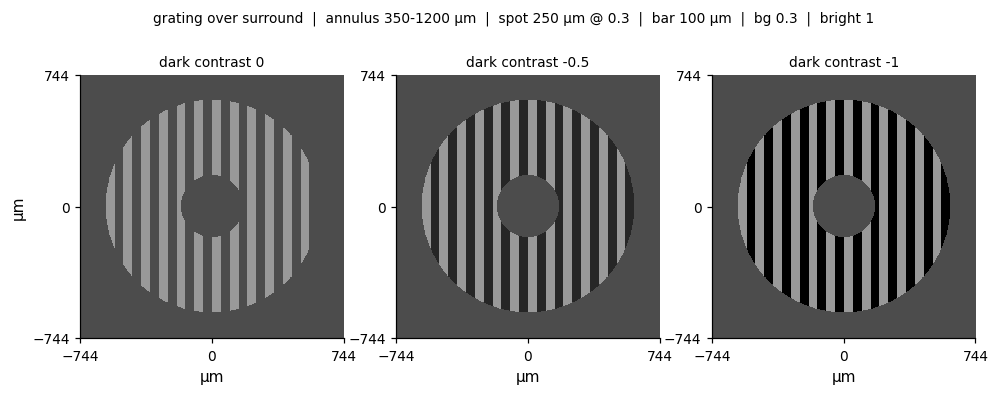

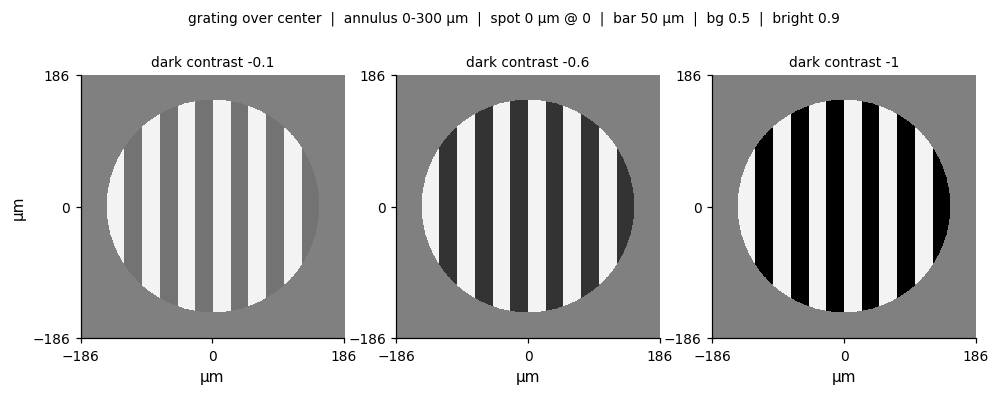

In [5]:
def block_params(block_id):
    exp = df_blocks.loc[df_blocks.block_id.eq(block_id), 'exp_name'].iloc[0]
    return ra.StimBlock(exp, int(block_id), verbose=False).df_epochs['epoch_parameters'].iloc[0]

on_block = df_blocks[df_blocks.cell_type_short.eq('ON-parasol')
                     & df_blocks.grating_site.eq('surround')].block_id.iloc[0]
off_block = df_blocks[df_blocks.cell_type_short.eq('OFF-parasol')
                      & df_blocks.grating_site.eq('center')].block_id.iloc[0]

sag.plot_stimulus_schematic(block_params(on_block))
sag.plot_stimulus_schematic(block_params(off_block));

## 4. Analyze one recording group

`analyze_group` pools the group's blocks, detects spikes (extracellular) or smooths and
baseline-subtracts (whole-cell), measures the response in the stimulus window, pools across bar
width and polarity, and returns the tuning curve with its cancellation point.

If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2025-10-15_E | RGC\ON-parasol | Cell6 | exc | grating surround | FW=0.0 bg=0.30 (FW0/bg0.3 (?R*)) | 209 epochs
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [-7.629 -8.343 -7.197 -5.819 -5.216 -3.932 -4.087 -2.81  -4.608 -5.64
 -4.993]
  baseline=-0.000 | crossing nearest=-0.300 interp=nan | cone pred=nan


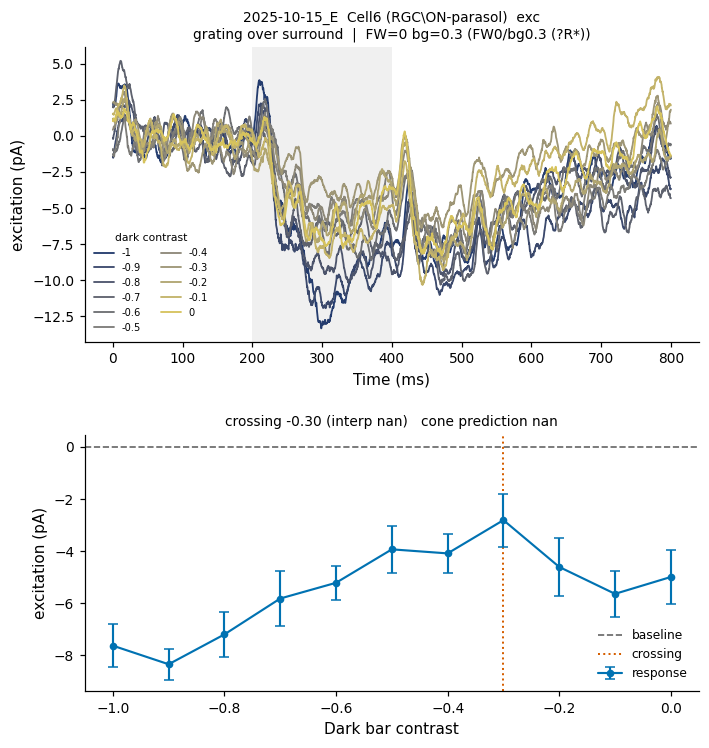

In [6]:
row = canonical.sort_values('epochs', ascending=False).iloc[0]
rec = sag.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                        online_analysis=row.onlineAnalysis)
sag.plot_group(rec);

## 5. Batch analyze and save

Records go to `<OUTPUT_DIR>/spot_annular_grating/records.h5` (one group per recording, holding
the tuning curve and mean traces) with `summary.csv` as the scalar index. Re-running a group
overwrites its record — the same upsert the MATLAB did on `spotAnnularGratingSummary.mat`.

This processes every canonical group; it takes a while, so it is the one slow cell in the
notebook.

In [7]:
# skip_existing leaves groups already in the store alone, so re-running the
# notebook does not redo hours of spike detection.
records = sag.analyze_all(canonical, save=True, plot=False, skip_existing=True)

If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.
analyzed 0/63 groups (62 already stored, skipped)
1 failed:
  2026-01-02_E_2 Cell7: FileNotFoundError: No h5 file found for experiment 2026-01-02_E_2.
Tried /Volumes/ChrisNewSSD/single_cell/fred


## 6. Measured cancellation, by light setting

Every record, plotted against the light level *as recorded* — no calibration needed. Blue dashes
are the mean per setting. Filled markers are settings that `RSTAR_TABLE` already converts to R*;
open markers are the ones still waiting on a calibration.

62 records | with R*: 23 | awaiting calibration: 39


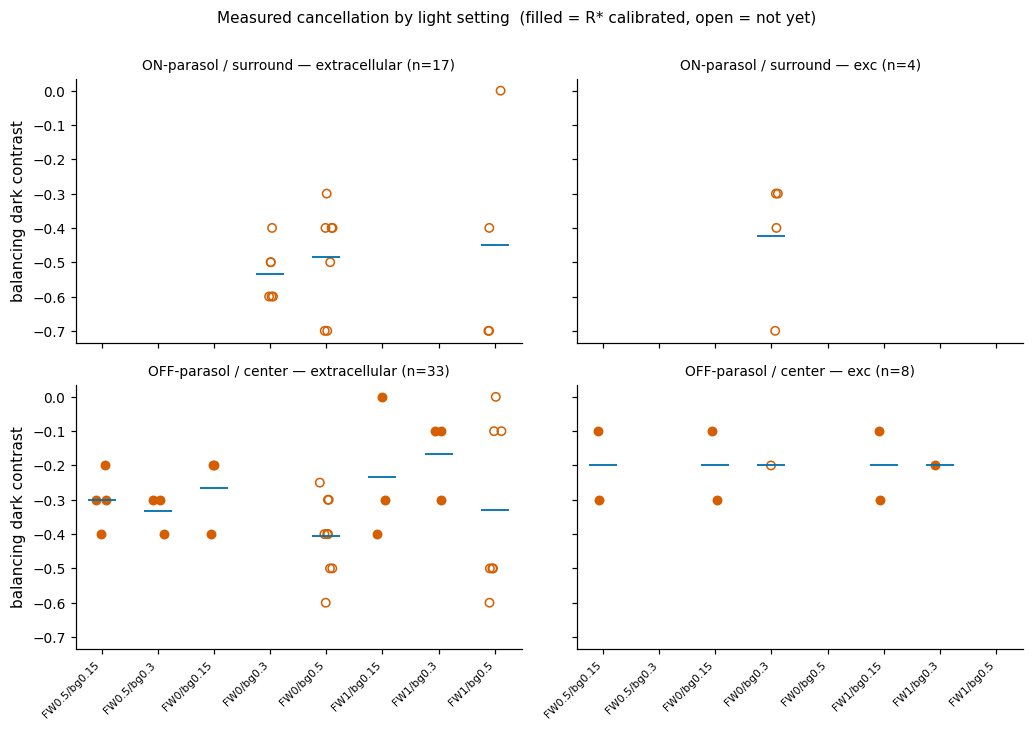

In [8]:
summary = sag.add_condition(sag.load_summary())
print(f'{len(summary)} records | with R*: {int(summary.rstar.notna().sum())}'
      f' | awaiting calibration: {int(summary.rstar.isna().sum())}')

sag.plot_crossing_by_light_setting(summary);

### Against the Weber prediction

The population figure from `populationSpotAnnularGrating.m`: the Weber/Naka-Rushton prediction
`R(I) = I/(I+I0)` drawn continuously across light level with each measured crossing on top, one
panel per condition × recording mode.

Only records with an R* can be placed on this axis, so the panels are as complete as the
calibration is. To fill them in, pass your own conversion — the cell below shows the call with
the settings this dataset needs.

39/62 records have no R* and are not plotted; they need a calibration for: FW0/bg0.3, FW0/bg0.5, FW1/bg0.5


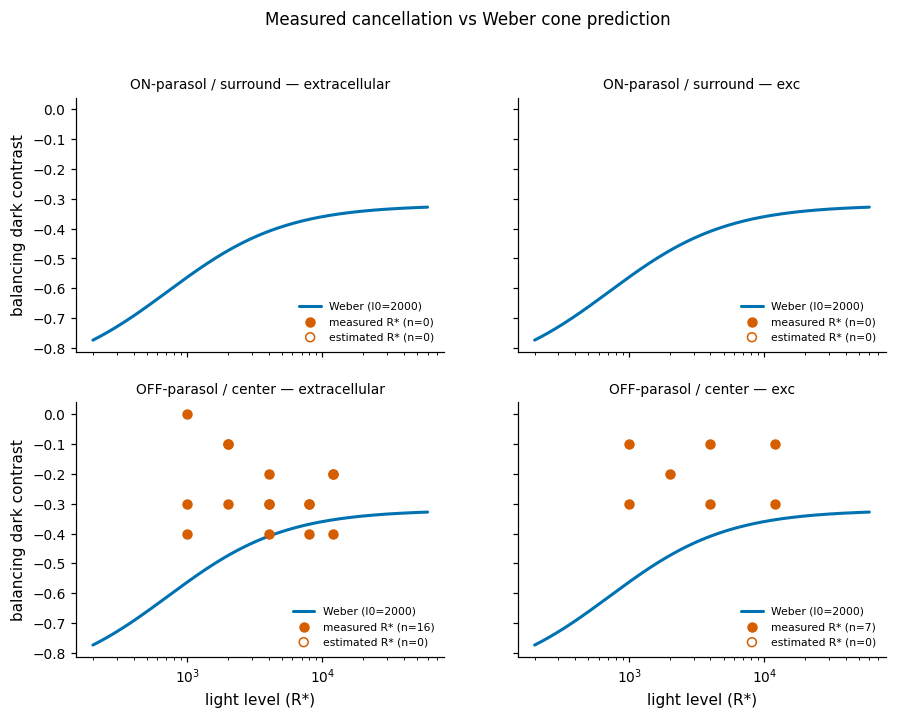

In [9]:
sag.plot_weber_comparison(summary);

In [10]:
# Supply measured R* for the settings above and everything re-plots, no
# re-analysis: crossings never depended on the light-level conversion.
#
# summary_cal = sag.apply_rstar_mapping(sag.load_summary(), {
#     (0.0, 0.30): ...,   # FW0/bg0.3
#     (0.0, 0.50): ...,   # FW0/bg0.5
#     (1.0, 0.50): ...,   # FW1/bg0.5
# })
# sag.plot_weber_comparison(sag.add_condition(summary_cal));

### Example data behind each panel

The recording with the most epochs in each condition × mode, with its own baseline, measured
crossing and the Weber prediction at that recording's light level.

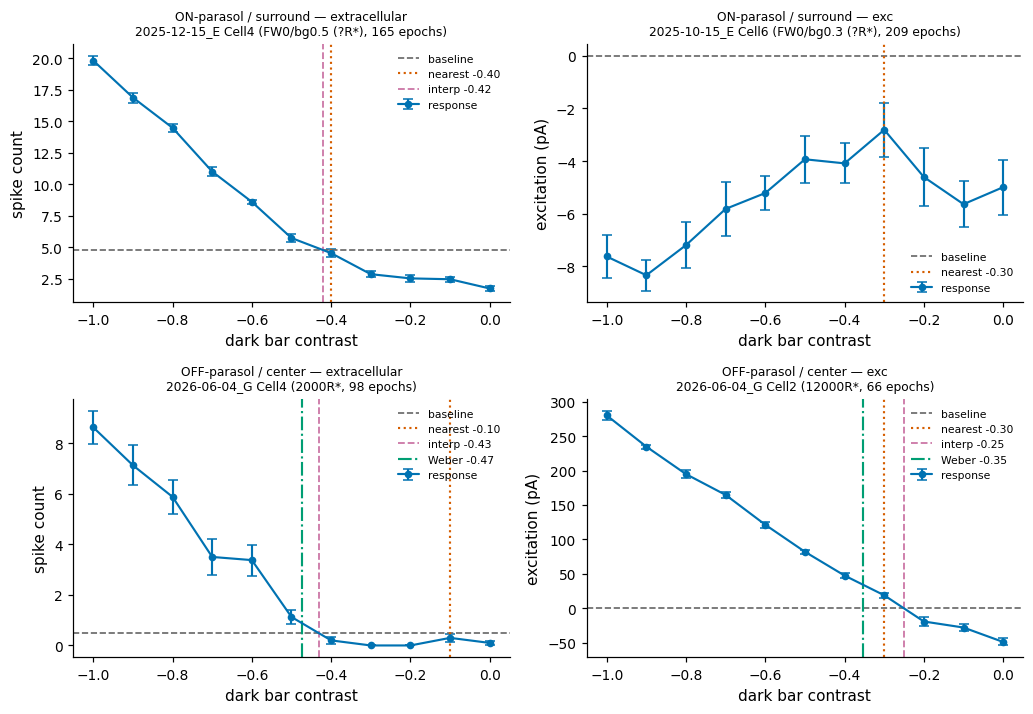

In [11]:
# Falls back to the stored records when the batch above was skipped.
sag.plot_condition_examples(records);

## 7. Come back later

`load_summary()` reads only the scalar index, so population work starts in a cold kernel with
no DataJoint and no SSD access; `load_records()` pulls full arrays for chosen keys.

In [12]:
summary = sag.add_condition(sag.load_summary())
sc.scroll_table(summary[['exp_name', 'cell_label', 'cell_type_short', 'online_analysis',
                         'grating_site', 'light_level', 'rstar', 'crossing_nearest',
                         'cone_pred_dark', 'n_epochs']], height=320)

full = sag.load_records([summary['key'].iloc[0]])[summary['key'].iloc[0]]
print('arrays in a record:', [k for k, v in full.items() if getattr(v, 'ndim', 0) > 0])
print('dark contrasts:', np.round(full['dark_contrasts'], 2))
print('tuning curve  :', np.round(full['resp_mean'], 2))

exp_name,cell_label,cell_type_short,online_analysis,grating_site,light_level,rstar,crossing_nearest,cone_pred_dark,n_epochs
2026-02-26_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.5,-0.3315789473684211,47
2026-02-26_E,Cell5,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.6,-0.3315789473684211,83
2026-04-03_E,Cell4,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.4,-0.3315789473684211,33
2026-04-04_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.25,-0.1693548387096775,30
2026-04-04_E,Cell1,OFF-parasol,extracellular,center,FW1/bg0.5 (?R*),,-0.5,-0.3076923076923077,20
2026-04-14_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.3,-0.3315789473684211,77
2026-04-14_E,Cell1,OFF-parasol,extracellular,center,FW1/bg0.5 (?R*),,-0.5,-0.4235294117647058,88
2026-04-14_E,Cell3,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.4,-0.3315789473684211,132
2026-04-14_E,Cell3,OFF-parasol,extracellular,center,FW1/bg0.5 (?R*),,-0.5,-0.4235294117647058,88
2026-04-23_E,Cell1,OFF-parasol,extracellular,center,FW0/bg0.5 (?R*),,-0.4,-0.3315789473684211,66


arrays in a record: ['bar_widths', 'dark_contrasts', 'resp_mean', 'resp_n', 'resp_sem', 'trace_time_ms', 'traces']
dark contrasts: [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1]
tuning curve  : [4.5  3.75 2.75 1.8  1.4  0.6  0.6  0.6  1.4  1.8 ]


## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-06-04_G/Cell4'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [13]:
sag.list_cells(canonical)

32 cells, 63 recording conditions in total


cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
2026-02-26_E/Cell1,OFF-parasol,1,47,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
2026-02-26_E/Cell5,,1,83,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
2026-04-03_E/Cell4,,1,33,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
2026-04-04_E/Cell1,,2,50,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-14_E/Cell1,,2,165,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-14_E/Cell3,,2,220,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell1,,2,99,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell2,,2,99,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-23_E/Cell6,,2,131,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
2026-04-24_E/Cell2,,2,88,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


,cell_id,cell_type,conditions,epochs,onlineAnalysis,grating_site,light_setting,light_level,filter_wheel_ndf,backgroundIntensity
0,2026-02-26_E/Cell1,OFF-parasol,1,47,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
1,2026-02-26_E/Cell5,OFF-parasol,1,83,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
2,2026-04-03_E/Cell4,OFF-parasol,1,33,extracellular,center,FW0/bg0.5,FW0/bg0.5 (?R*),0.0,0.5
3,2026-04-04_E/Cell1,OFF-parasol,2,50,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
4,2026-04-14_E/Cell1,OFF-parasol,2,165,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
5,2026-04-14_E/Cell3,OFF-parasol,2,220,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
6,2026-04-23_E/Cell1,OFF-parasol,2,99,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
7,2026-04-23_E/Cell2,OFF-parasol,2,99,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
8,2026-04-23_E/Cell6,OFF-parasol,2,131,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5
9,2026-04-24_E/Cell2,OFF-parasol,2,88,extracellular,center,"FW0/bg0.5, FW1/bg0.5","FW0/bg0.5 (?R*), FW1/bg0.5 (?R*)","0.0, 1.0",0.5


2026-06-04_G/Cell4: 10 recording condition(s), 556 epochs, cell type OFF-parasol


onlineAnalysis,grating_site,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,blocks,epochs,block_ids
extracellular,center,FW0.5/bg0.15,4000R*,0.5,0.15,1,66,35051
extracellular,center,FW0/bg0.15,12000R*,0.0,0.15,1,66,35052
extracellular,center,FW1/bg0.15,1000R*,1.0,0.15,1,66,35053
extracellular,center,FW1/bg0.3,2000R*,1.0,0.3,2,98,"35054, 35056"
extracellular,center,FW0.5/bg0.3,8000R*,0.5,0.3,1,61,35055
exc,center,FW0.5/bg0.15,4000R*,0.5,0.15,1,32,35061
exc,center,FW1/bg0.15,1000R*,1.0,0.15,1,36,35062
exc,center,FW1/bg0.3,2000R*,1.0,0.3,1,46,35063
exc,center,FW0/bg0.3,FW0/bg0.3 (?R*),0.0,0.3,1,19,35064
exc,center,FW0/bg0.15,12000R*,0.0,0.15,1,66,35065


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 2344 peaks


Trial 1: Found 11 spikes
Trial 2: Found 2420 peaks
Trial 2: Found 12 spikes
Trial 3: Found 2409 peaks
Trial 3: Found 10 spikes
Trial 4: Found 2394 peaks
Trial 4: Found 8 spikes
Trial 5: Found 2390 peaks


...

2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=1.0 bg=0.30 (2000R*) | 46 epochs
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [411.754 312.725 252.178 199.681 154.118 122.918  52.816  27.848  -2.768
 -21.231 -10.958]
  baseline=0.000 | crossing nearest=-0.200 interp=-0.209 | cone pred=-0.474


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=0.0 bg=0.30 (FW0/bg0.3 (?R*)) | 19 epochs
  dark contrasts : [-0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [538.162 368.38  303.676 203.43  135.31   89.356  15.882  -7.057 -28.104
 -57.117]
  baseline=0.000 | crossing nearest=-0.200 interp=-0.231 | cone pred=nan


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2026-06-04_G | RGC\OFF-parasol | Cell4 | exc | grating center | FW=0.0 bg=0.15 (12000R*) | 66 epochs
  dark contrasts : [-1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1  0. ]
  response       : [528.472 460.775 379.575 320.605 229.444 149.773  95.894  27.582   8.828
  -0.826 -47.978]
  baseline=-0.000 | crossing nearest=-0.100 interp=-0.109 | cone pred=-0.354
analyzed 10/10 conditions for 2026-06-04_G/Cell4


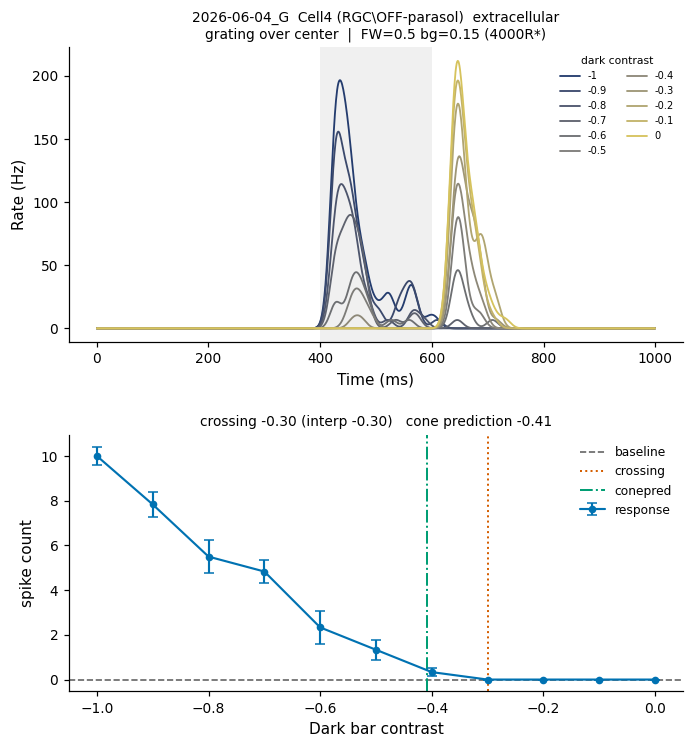

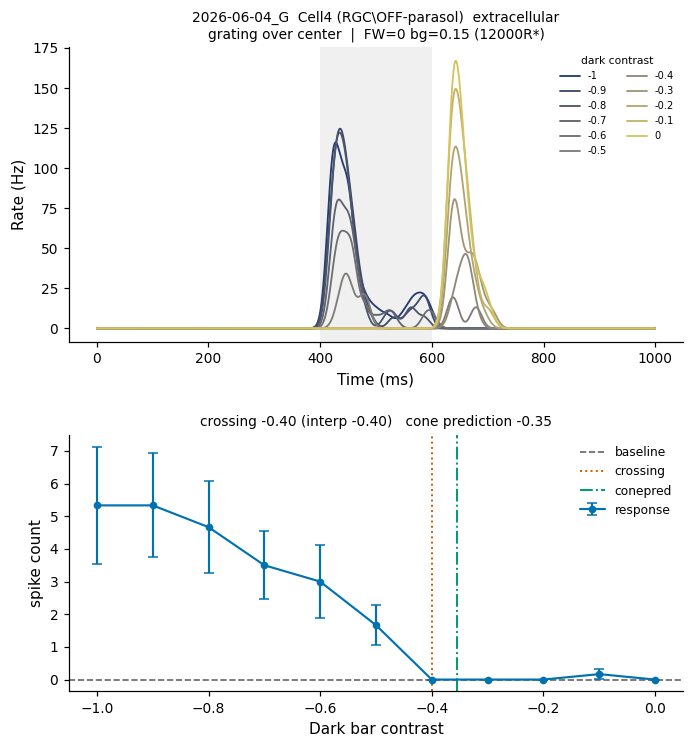

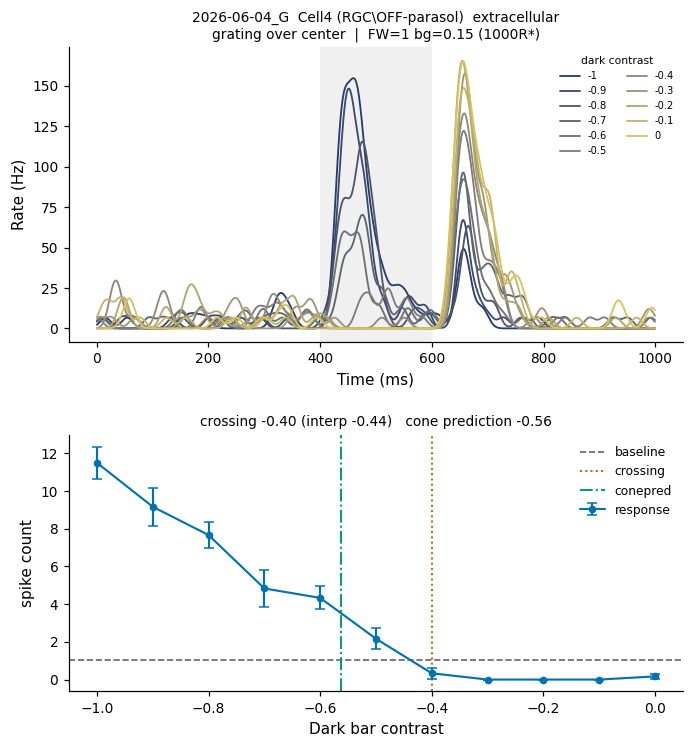

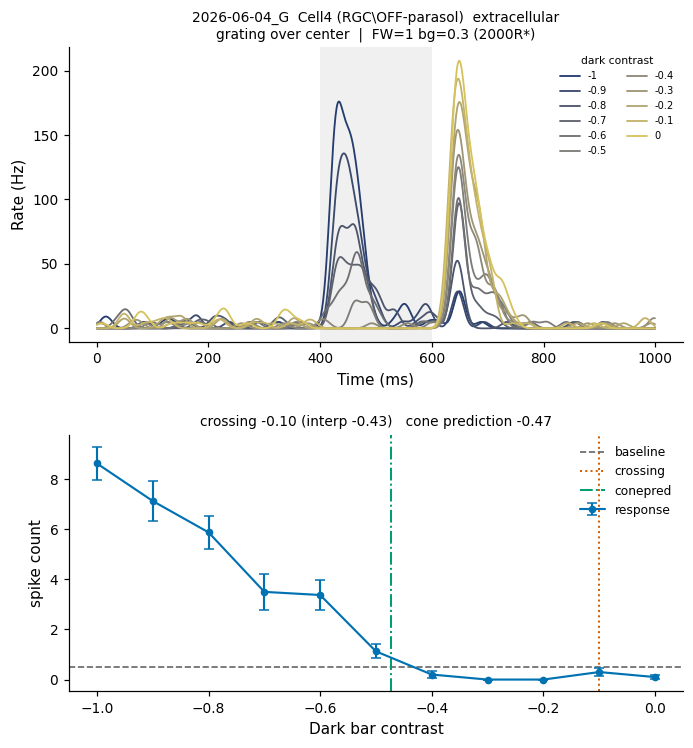

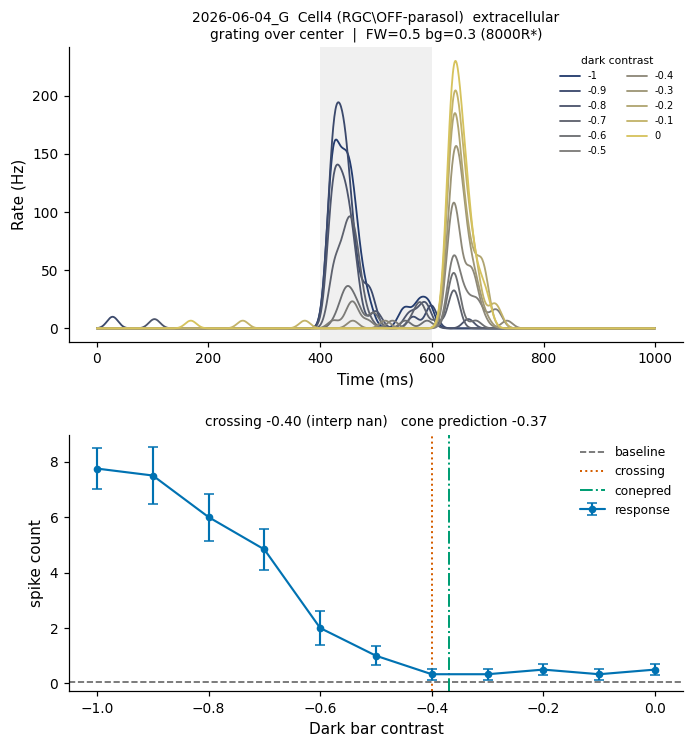

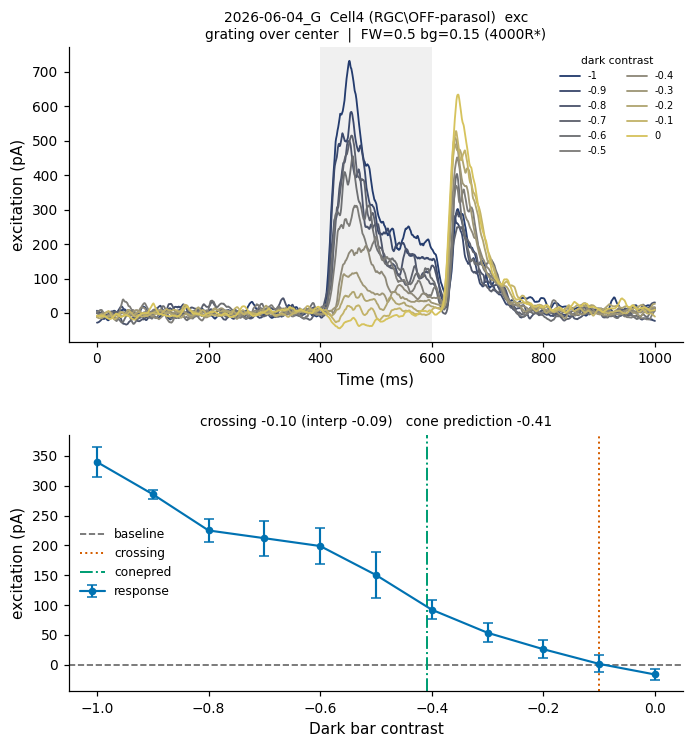

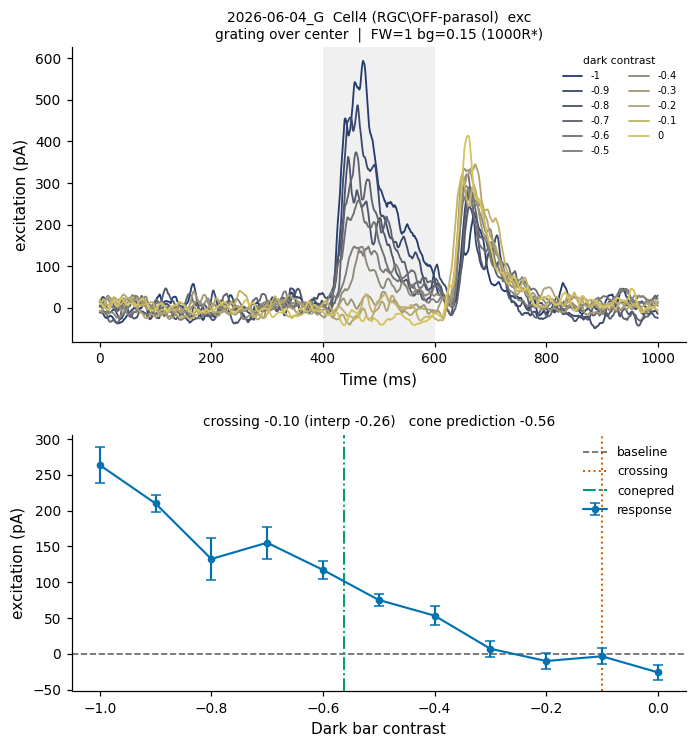

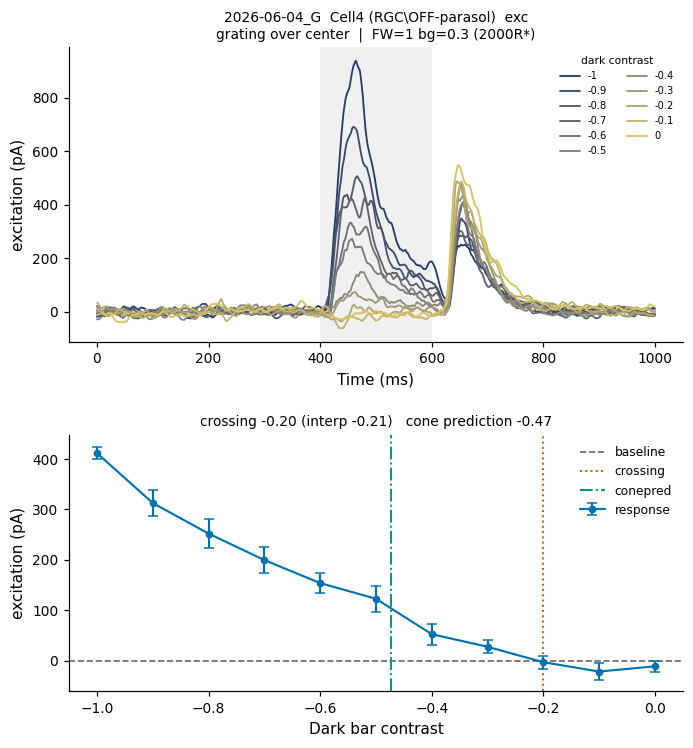

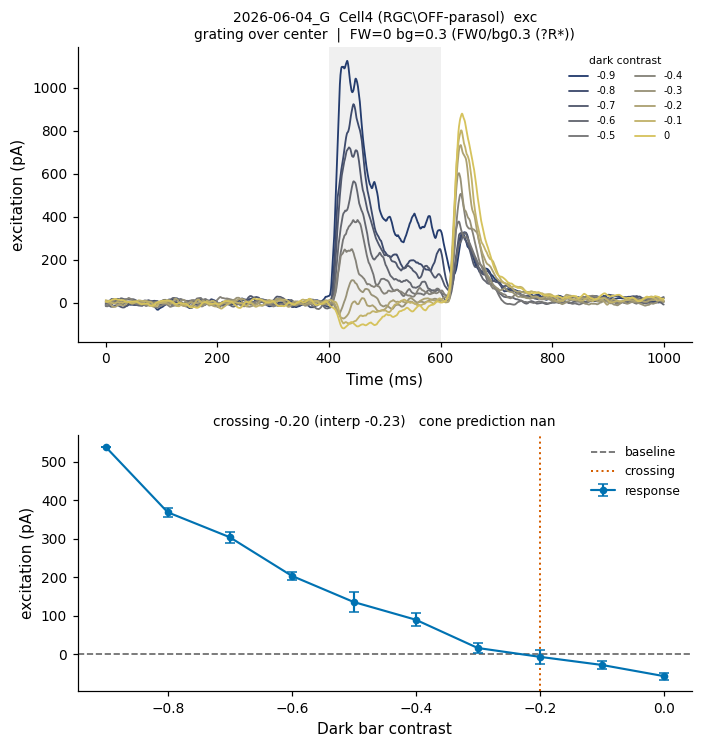

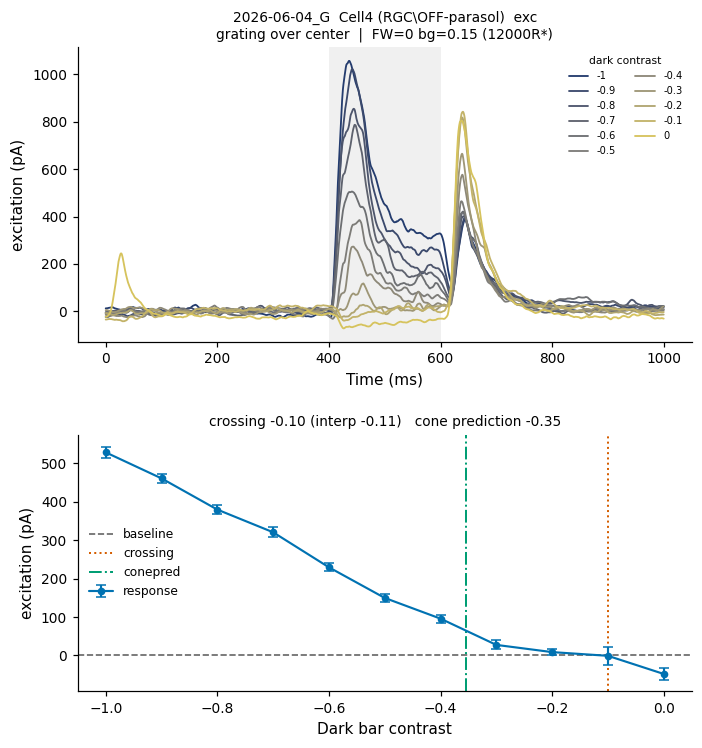

In [14]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-06-04_G/Cell4'

cell_records = sag.inspect_cell(CELL, canonical)